# 📘 Домашнє завдання №21. Введення до нейромереж


##  Мета
Побудувати нейронну мережу в PyTorch для задачі бінарної класифікації:
- 1 → пасажир вижив
- 0 → пасажир не вижив

---

##  Датасет
Використати датасет **Titanic** (наприклад `titanic.csv` або Kaggle Titanic dataset).

---

##  1. Попередня обробка даних

Необхідно:

- Вибрати ознаки:
  - Pclass
  - Sex
  - Age
  - Fare
  - (за бажанням: SibSp, Parch)

- Обробити пропущені значення:
  - заповнити або видалити

- Перетворити категоріальні змінні:
  - `Sex` → 0 / 1

- Нормалізувати числові ознаки:
  - використати `StandardScaler`

⚠️ Важливо:
- scaler fit робити **тільки на train set**
- test set тільки transform

---

## 2. Розбиття даних

Розділити датасет на:
- train (80%)
- test (20%)

---

## 3. Побудова моделі (PyTorch)

Створити нейронну мережу:

- Input layer: кількість ознак
- 1–2 hidden layers
- Activation function: ReLU
- Output layer: 1 нейрон
- Activation: Sigmoid

---

## 4. Навчання моделі

Використати:

- Loss function:
  - `BCELoss`

- Optimizer:
  - `Adam`

- epochs: 50–150 (на вибір)

Під час навчання:
- виводити loss кожні 10 епох

---

## 5. Оцінка моделі

Порахувати:

- Accuracy на test set
- (опційно) confusion matrix

---

## 6. Експерименти

Спробувати:

- змінити кількість нейронів у hidden layers
- змінити learning rate
- додати ще один hidden layer

---

## Результати (що здати)

Потрібно надати:

- код навчання моделі
- фінальний accuracy
- короткий висновок:
  - що вплинуло на результат
  - яка конфігурація дала найкращий результат

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
#     "kagglehub",
#     "kagglesdk",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "seaborn",
#     "torch",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
hm_version = 21
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [3]:
# Downloading data

import pandas as pd
import apps.main as mn

# Input data
update_db = False
db_file_name = f"resources/store_hw{hm_version}.db"

# Solution
pd.options.display.float_format = "{:g}".format  # type: ignore
titanic_dataset = mn.download_and_extract_from_kagglehub("yasserh/titanic-dataset",
                                                         "Titanic-Dataset.csv",
                                                         db_file_name,
                                                         update_db=update_db)

# Print result
display(titanic_dataset)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30,C148,C


# ✅ Рішення: 1. Попередня обробка даних

Необхідно:

- Вибрати ознаки:
  - Pclass
  - Sex
  - Age
  - Fare
  - (за бажанням: SibSp, Parch)

- Обробити пропущені значення:
  - заповнити або видалити

- Перетворити категоріальні змінні:
  - `Sex` → 0 / 1

In [4]:
# Data analysis

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
target_value = "Survived"
data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних"))
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(data_set)

### Аналіз даних

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,12
Кількість числових ознак,7
Кількість категоріальних ознак,5
Пропущені значення,є


,count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


,Types
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30,C148,C


In [5]:
# Data preparation

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Input data
age_col_name = "Age"
fare_col_name = "Fare"
sex_col_name = "Sex"
sibsp_col_name = "SibSp"
parch_col_name = "Parch"
family_col_name = "FamilySize"
fil_num_col_list = ["Age"]
save_col_list = ["Pclass", "Sex", "Age", "Fare", family_col_name, target_value]

# Solution
titanic_dataset[family_col_name] = (
    titanic_dataset.apply(lambda df_row: df_row[sibsp_col_name] + df_row[parch_col_name] + 1, axis=1).
    astype(int))

titanic_dataset = titanic_dataset[save_col_list]

preprocessor = ColumnTransformer([
    ("fil_num", SimpleImputer(strategy="median"), fil_num_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
transformed_data = preprocessor.fit_transform(titanic_dataset)
titanic_dataset = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

# Корегування даних
titanic_dataset[age_col_name] = titanic_dataset[age_col_name].round().astype(int)
titanic_dataset[fare_col_name] = titanic_dataset[fare_col_name].round(2).astype(float)
titanic_dataset[sex_col_name] = titanic_dataset[sex_col_name].map({"male": 1, "female": 0})

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Підготовка даних (titanic_dataset)"))
rp.print_pd_report("Параметри таблиці без кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))
display(data_set)


### Підготовка даних (titanic_dataset)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,6
Кількість числових ознак,6
Кількість категоріальних ознак,0
Пропущені значення,немає


,Types
Age,int64
Pclass,int64
Sex,int64
Fare,float64
FamilySize,int64
Survived,int64


,Age,Pclass,Sex,Fare,FamilySize,Survived
0,22,3,1,7.25,2,0
1,38,1,0,71.28,2,1
2,26,3,0,7.92,1,1
3,35,1,0,53.1,2,1
4,35,3,1,8.05,1,0
...,...,...,...,...,...,...
886,27,2,1,13,1,0
887,19,1,0,30,1,1
888,28,3,0,23.45,4,0
889,26,1,1,30,1,1


# ✅ Рішення: 2. Розбиття даних

Розділити датасет на:
- train (80%)
- test (20%)

Нормалізувати числові ознаки:
  - використати `StandardScaler`

⚠️ Важливо:
- scaler fit робити **тільки на train set**
- test set тільки transform

In [6]:
# Splitting data

import gc
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Input data
test_ratio = 0.2
rng_seed = 42

# Solution
X_data = titanic_dataset.drop(columns=[target_value])
Y_data = titanic_dataset[target_value]
input_data_cols_list = X_data.columns.tolist()

del titanic_dataset

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data,
                                                    test_size=test_ratio,
                                                    stratify=Y_data,
                                                    random_state=rng_seed,
                                                    shuffle=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print results
display(Markdown(f"### Розбиття даних"))

display(Markdown(f"**Датасет: (titanic_dataset)**"))
display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True).round(2)
], axis=1).style.format("{:g}").set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True).round(2)
], axis=1).style.format("{:g}").set_caption("Вибірка для тестування"))

# конвертуємо
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# аналог .unsqueeze(1)
Y_train = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)
Y_test = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Clean
_ = gc.collect()

### Розбиття даних

**Датасет: (titanic_dataset)**

,count,proportion
Survived,,
0,439,0.62
1,273,0.38


,count,proportion
Survived,,
0,110,0.61
1,69,0.39


# ✅ Рішення: 3. Побудова моделі (PyTorch)

Створити нейронну мережу:

- Input layer: кількість ознак
- 1–2 hidden layers
- Activation function: ReLU
- Output layer: 1 нейрон
- Activation: Sigmoid

In [7]:
# Model creating

import torch.nn as nn

# Input data
rng_seed = 42
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

# Print results
print(model)


Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


# ✅ Рішення: 4. Навчання моделі

Використати:

- Loss function:
  - `BCELoss`

- Optimizer:
  - `Adam`

- epochs: 50–150 (на вибір)

Під час навчання:
- виводити loss кожні 10 епох

In [8]:
# Model training

import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
lr = 0.01
n_step = 10
n_epochs = 150

# Solution
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

# Print results


Training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 10, Loss: 0.6143, Status: 6.67%
Epoch: 20, Loss: 0.4811, Status: 13.33%
Epoch: 30, Loss: 0.4347, Status: 20.00%
Epoch: 40, Loss: 0.4166, Status: 26.67%
Epoch: 50, Loss: 0.4087, Status: 33.33%
Epoch: 60, Loss: 0.4031, Status: 40.00%
Epoch: 70, Loss: 0.3975, Status: 46.67%
Epoch: 80, Loss: 0.3914, Status: 53.33%
Epoch: 90, Loss: 0.3863, Status: 60.00%
Epoch: 100, Loss: 0.3799, Status: 66.67%
Epoch: 110, Loss: 0.3745, Status: 73.33%
Epoch: 120, Loss: 0.3705, Status: 80.00%
Epoch: 130, Loss: 0.3670, Status: 86.67%
Epoch: 140, Loss: 0.3643, Status: 93.33%
Epoch: 150, Loss: 0.3619, Status: 100.00%


# ✅ Рішення: 5. Оцінка моделі

Порахувати:

- Accuracy на test set
- (опційно) confusion matrix

### Оцінка моделі

Attribute,Result
Confusion Matrix,[[97 13] [23 46]]
Accuracy (Точність),0.7989
Precision (Влучність),0.7797
Recall (Повнота),0.6667
F1-score,0.7188
Receiver Operating Characteristic (ROC-AUC),0.8476
Average Precision (AP),0.8176


              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84       110
         1.0       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



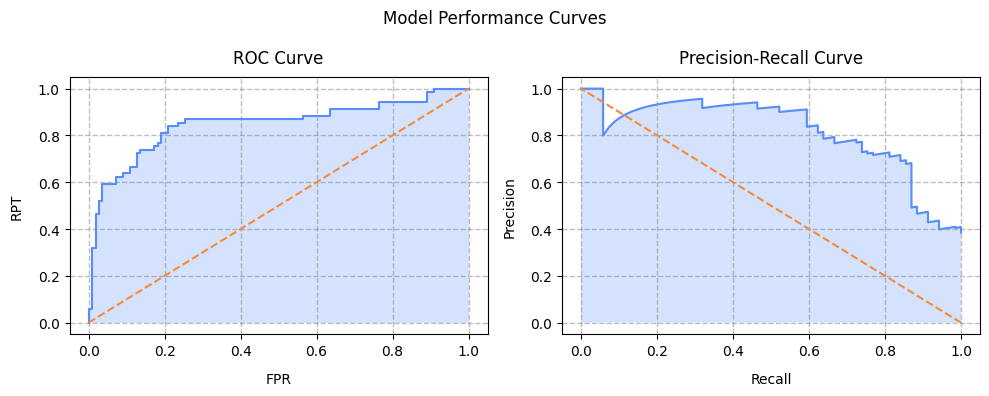

In [9]:
# Model evaluation

import torch

# Input data

# Solution
# вимикаємо навчання і переходимо в режим тестування
model.eval()

with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі"))
df_base = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)


# ✅ Рішення: 6. Експерименти

Спробувати:

- змінити кількість нейронів у hidden layers
- змінити learning rate
- додати ще один hidden layer

Training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 10, Loss: 0.5508, Status: 6.67%
Epoch: 20, Loss: 0.4511, Status: 13.33%
Epoch: 30, Loss: 0.4208, Status: 20.00%
Epoch: 40, Loss: 0.4070, Status: 26.67%
Epoch: 50, Loss: 0.3973, Status: 33.33%
Epoch: 60, Loss: 0.3892, Status: 40.00%
Epoch: 70, Loss: 0.3804, Status: 46.67%
Epoch: 80, Loss: 0.3732, Status: 53.33%
Epoch: 90, Loss: 0.3673, Status: 60.00%
Epoch: 100, Loss: 0.3619, Status: 66.67%
Epoch: 110, Loss: 0.3565, Status: 73.33%
Epoch: 120, Loss: 0.3515, Status: 80.00%
Epoch: 130, Loss: 0.3466, Status: 86.67%
Epoch: 140, Loss: 0.3413, Status: 93.33%
Epoch: 150, Loss: 0.3367, Status: 100.00%


### Оцінка моделі №1 - змінена кількість нейронів

Attribute,Result
Confusion Matrix,[[93 17] [22 47]]
Accuracy (Точність),0.7821
Precision (Влучність),0.7344
Recall (Повнота),0.6812
F1-score,0.7068
Receiver Operating Characteristic (ROC-AUC),0.8358
Average Precision (AP),0.7895


              precision    recall  f1-score   support

         0.0       0.81      0.85      0.83       110
         1.0       0.73      0.68      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



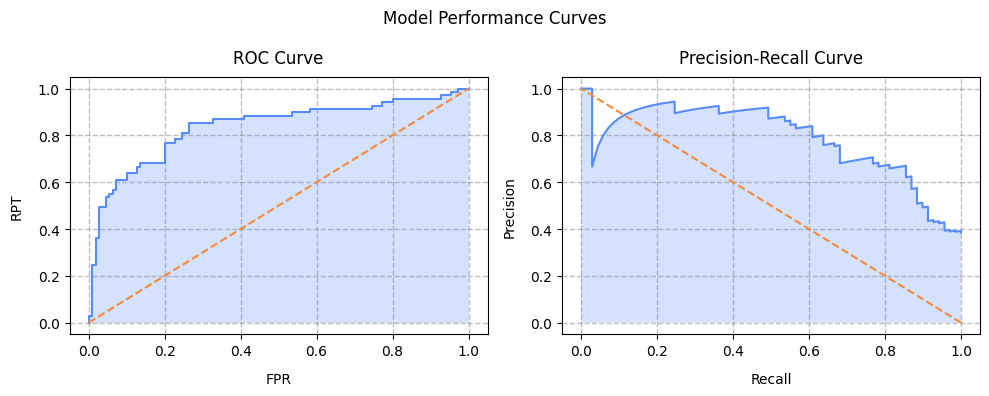

Sequential(
  (0): Linear(in_features=5, out_features=25, bias=True)
  (1): ReLU()
  (2): Linear(in_features=25, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
  (5): Sigmoid()
)


In [10]:
# Experiment 1

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
rng_seed = 42
lr = 0.01
n_step = 10
n_epochs = 150
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, n_inputs ** 2),
    nn.ReLU(),
    nn.Linear(n_inputs ** 2, n_inputs * 2),
    nn.ReLU(),
    nn.Linear(n_inputs * 2, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

model.eval()
with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі №1 - змінена кількість нейронів"))
df_exp1 = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)
print(model)

Training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 10, Loss: 0.5616, Status: 6.67%
Epoch: 20, Loss: 0.4475, Status: 13.33%
Epoch: 30, Loss: 0.4185, Status: 20.00%
Epoch: 40, Loss: 0.4091, Status: 26.67%
Epoch: 50, Loss: 0.4016, Status: 33.33%
Epoch: 60, Loss: 0.3946, Status: 40.00%
Epoch: 70, Loss: 0.3869, Status: 46.67%
Epoch: 80, Loss: 0.3806, Status: 53.33%
Epoch: 90, Loss: 0.3761, Status: 60.00%
Epoch: 100, Loss: 0.3727, Status: 66.67%
Epoch: 110, Loss: 0.3700, Status: 73.33%
Epoch: 120, Loss: 0.3667, Status: 80.00%
Epoch: 130, Loss: 0.3636, Status: 86.67%
Epoch: 140, Loss: 0.3609, Status: 93.33%
Epoch: 150, Loss: 0.3582, Status: 100.00%


### Оцінка моделі №2 - змінено крок навчання

Attribute,Result
Confusion Matrix,[[96 14] [25 44]]
Accuracy (Точність),0.7821
Precision (Влучність),0.7586
Recall (Повнота),0.6377
F1-score,0.6929
Receiver Operating Characteristic (ROC-AUC),0.8462
Average Precision (AP),0.8280


              precision    recall  f1-score   support

         0.0       0.79      0.87      0.83       110
         1.0       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



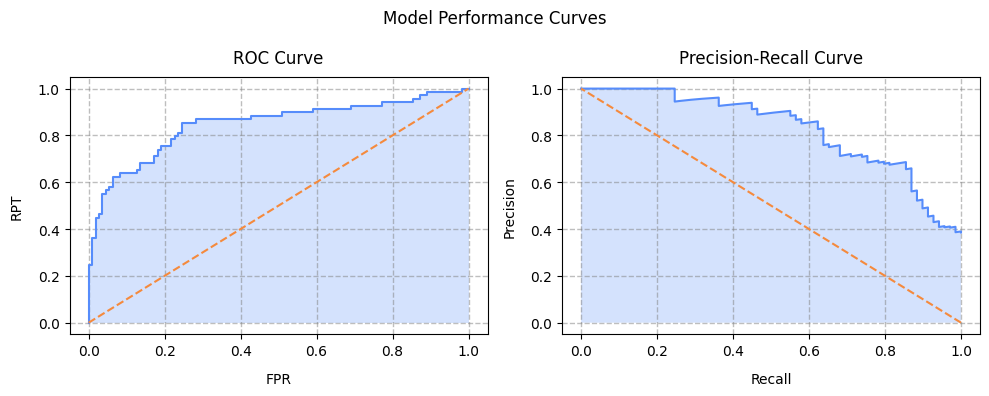

Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


In [11]:
# Experiment 2

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
rng_seed = 42
lr = 0.015
n_step = 10
n_epochs = 150
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

model.eval()
with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі №2 - змінено крок навчання"))
df_exp2 = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)
print(model)

Training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 10, Loss: 0.5671, Status: 6.67%
Epoch: 20, Loss: 0.4774, Status: 13.33%
Epoch: 30, Loss: 0.4454, Status: 20.00%
Epoch: 40, Loss: 0.4188, Status: 26.67%
Epoch: 50, Loss: 0.4004, Status: 33.33%
Epoch: 60, Loss: 0.3891, Status: 40.00%
Epoch: 70, Loss: 0.3793, Status: 46.67%
Epoch: 80, Loss: 0.3719, Status: 53.33%
Epoch: 90, Loss: 0.3657, Status: 60.00%
Epoch: 100, Loss: 0.3590, Status: 66.67%
Epoch: 110, Loss: 0.3520, Status: 73.33%
Epoch: 120, Loss: 0.3450, Status: 80.00%
Epoch: 130, Loss: 0.3375, Status: 86.67%
Epoch: 140, Loss: 0.3311, Status: 93.33%
Epoch: 150, Loss: 0.3238, Status: 100.00%


### Оцінка моделі №3 - змінена кількість прихованих шарів

Attribute,Result
Confusion Matrix,[[97 13] [20 49]]
Accuracy (Точність),0.8156
Precision (Влучність),0.7903
Recall (Повнота),0.7101
F1-score,0.7481
Receiver Operating Characteristic (ROC-AUC),0.8514
Average Precision (AP),0.8188


              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85       110
         1.0       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



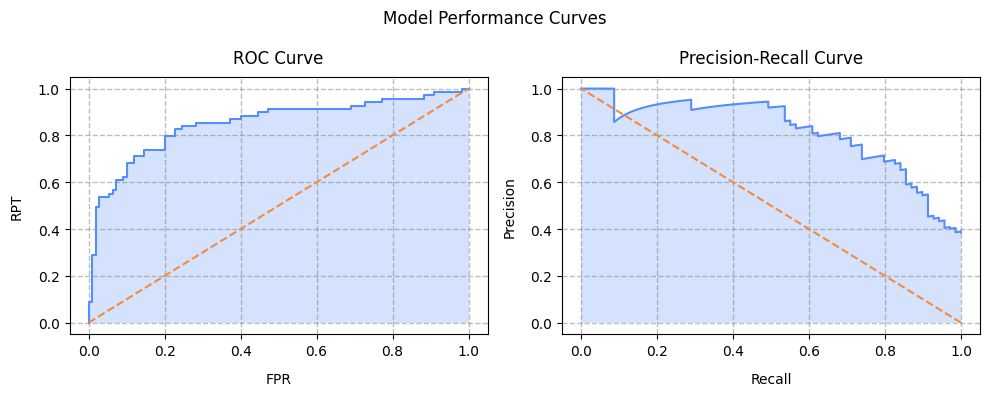

Sequential(
  (0): Linear(in_features=5, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=8, bias=True)
  (5): ReLU()
  (6): Linear(in_features=8, out_features=1, bias=True)
  (7): Sigmoid()
)


In [12]:
# Experiment 3

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
rng_seed = 42
lr = 0.01
n_step = 10
n_epochs = 150
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

model.eval()

with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі №3 - змінена кількість прихованих шарів"))
df_exp3 = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)
print(model)

Training:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 10, Loss: 0.5245, Status: 6.67%
Epoch: 20, Loss: 0.4458, Status: 13.33%
Epoch: 30, Loss: 0.4405, Status: 20.00%
Epoch: 40, Loss: 0.4280, Status: 26.67%
Epoch: 50, Loss: 0.4216, Status: 33.33%
Epoch: 60, Loss: 0.4155, Status: 40.00%
Epoch: 70, Loss: 0.4113, Status: 46.67%
Epoch: 80, Loss: 0.4083, Status: 53.33%
Epoch: 90, Loss: 0.4058, Status: 60.00%
Epoch: 100, Loss: 0.4034, Status: 66.67%
Epoch: 110, Loss: 0.4009, Status: 73.33%
Epoch: 120, Loss: 0.3982, Status: 80.00%
Epoch: 130, Loss: 0.3956, Status: 86.67%
Epoch: 140, Loss: 0.3933, Status: 93.33%
Epoch: 150, Loss: 0.3909, Status: 100.00%


### Оцінка моделі №4 - змінена функція активації

Attribute,Result
Confusion Matrix,[[103 7] [ 23 46]]
Accuracy (Точність),0.8324
Precision (Влучність),0.8679
Recall (Повнота),0.6667
F1-score,0.7541
Receiver Operating Characteristic (ROC-AUC),0.8609
Average Precision (AP),0.8342


              precision    recall  f1-score   support

         0.0       0.82      0.94      0.87       110
         1.0       0.87      0.67      0.75        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.84      0.83      0.83       179



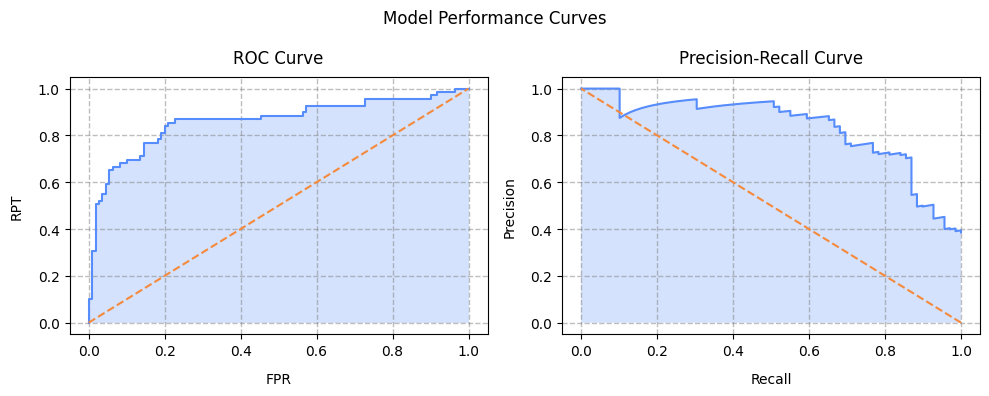

In [13]:
# Experiment 4

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
rng_seed = 42
lr = 0.01
n_step = 10
n_epochs = 150
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ELU(),
    nn.Linear(16, 8),
    nn.ELU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

model.eval()

with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі №4 - змінена функція активації"))
df_exp4 = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)
# print(model)

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 100, Loss: 0.4034, Status: 10.00%
Epoch: 200, Loss: 0.3782, Status: 20.00%
Epoch: 300, Loss: 0.3604, Status: 30.00%
Epoch: 400, Loss: 0.3325, Status: 40.00%
Epoch: 500, Loss: 0.3148, Status: 50.00%
Epoch: 600, Loss: 0.3047, Status: 60.00%
Epoch: 700, Loss: 0.2984, Status: 70.00%
Epoch: 800, Loss: 0.2936, Status: 80.00%
Epoch: 900, Loss: 0.2906, Status: 90.00%
Epoch: 1000, Loss: 0.2865, Status: 100.00%


### Оцінка моделі №5 - змінено кількість епох

Attribute,Result
Confusion Matrix,[[90 20] [24 45]]
Accuracy (Точність),0.7542
Precision (Влучність),0.6923
Recall (Повнота),0.6522
F1-score,0.6716
Receiver Operating Characteristic (ROC-AUC),0.7893
Average Precision (AP),0.7460


              precision    recall  f1-score   support

         0.0       0.79      0.82      0.80       110
         1.0       0.69      0.65      0.67        69

    accuracy                           0.75       179
   macro avg       0.74      0.74      0.74       179
weighted avg       0.75      0.75      0.75       179



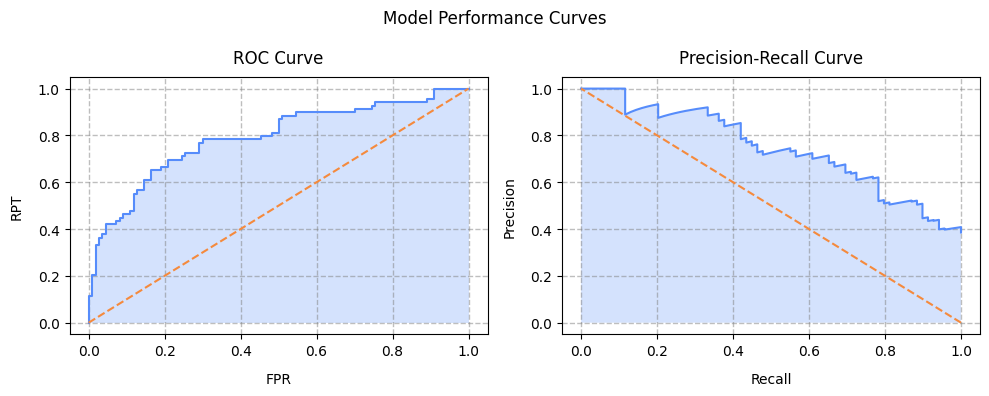

In [14]:
# Experiment 5

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Input data
rng_seed = 42
lr = 0.01
n_step = 100
n_epochs = 1000
n_inputs = len(input_data_cols_list)

# Solution
torch.manual_seed(rng_seed)

model = nn.Sequential(
    nn.Linear(n_inputs, 16),
    nn.ELU(),
    nn.Linear(16, 8),
    nn.ELU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % n_step == 0:
        tqdm.write(f"Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Status: {(epoch + 1.0) / n_epochs:.2%}")

model.eval()

with torch.no_grad():
    Y_prob = model(X_test)
    Y_pred = (Y_prob >= 0.5).float()

# Print results
display(Markdown(f"### Оцінка моделі №5 - змінено кількість епох"))
df_exp5 = mn.calc_class_metrics(Y_test, Y_pred, Y_prob)
# print(model)

# ✅ Результати

Потрібно:
- фінальний accuracy
- короткий висновок:
  - що вплинуло на результат
  - яка конфігурація дала найкращий результат

In [15]:
# Comparing models

from apps.reporter import Reporter

# Input data
models = [
    ("Базова модель", df_base),
    ("Змінена кількість нейронів", df_exp1),
    ("Змінено крок навчання", df_exp2),
    ("Змінена кількість прихованих шарів", df_exp3),
    ("Змінена функція активації", df_exp4),
    ("Змінено кількість епох", df_exp3),
]

# Solution

# Print results
display(Markdown(f"### Порівняння навчених нейронних моделей"))
Reporter.print_concat_pd_reports(models, "Порівняння результатів навчених моделей")

### Порівняння навчених нейронних моделей

,Confusion Matrix,Accuracy (Точність),Precision (Влучність),Recall (Повнота),F1-score,Receiver Operating Characteristic (ROC-AUC),Average Precision (AP)
Базова модель,[[97 13] [23 46]],0.7989,0.7797,0.6667,0.7188,0.8476,0.8176
Змінена кількість нейронів,[[93 17] [22 47]],0.7821,0.7344,0.6812,0.7068,0.8358,0.7895
Змінено крок навчання,[[96 14] [25 44]],0.7821,0.7586,0.6377,0.6929,0.8462,0.8280
Змінена кількість прихованих шарів,[[97 13] [20 49]],0.8156,0.7903,0.7101,0.7481,0.8514,0.8188
Змінена функція активації,[[103 7] [ 23 46]],0.8324,0.8679,0.6667,0.7541,0.8609,0.8342
Змінено кількість епох,[[97 13] [20 49]],0.8156,0.7903,0.7101,0.7481,0.8514,0.8188


Висновок. Опираючись на результати базової моделі та порівнюючи з нею модифіковані моделі, маємо наступне:

- зміна кількості нейронів і кроку навчання — порішило результат, за метриками, на 0.02 за точністю;
- зміна кількості прихованих шарів і кількості епох — покращило результат, за метриками, на 0.02 за точністю;
- зміна функції активації — дала найкращий результат, де покращила результат, за метриками, на 0.03 за точністю;

Ці результати валідні лише для даного випадку, якщо ж змінювати параметри в інші діапазони, то можна досягти кращих результатів.